<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/NB5_Sesion2_Practica_Rapida_10min.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 4 · Estadística Aplicada y Confiabilidad de Activos
## Sesión 2 — Confiabilidad de activos y simulación de fallas

Programa de Certificación en Ciencia de Datos aplicada al Mantenimiento Predictivo

### Notebook 5 · Práctica rápida (10 minutos) — Compresor de Aire

**Objetivo:** repetir el flujo del Notebook 4 con el **Compresor de Aire**, un equipo con comportamiento de **mortalidad infantil** (β<1). Tienes 10 minutos — apóyate en tu asistente de IA para resolver dudas de sintaxis, pero interpreta tú los resultados.

In [29]:
import numpy as np
import pandas as pd

EQUIPOS = {
    "Bomba Centrífuga":       {"beta": 2.8, "eta": 850,  "n_fallas": 60},
    "Motor Eléctrico":        {"beta": 1.0, "eta": 1200, "n_fallas": 55},
    "Compresor de Aire":      {"beta": 0.6, "eta": 400,  "n_fallas": 70},
    "Ventilador Industrial":  {"beta": 2.2, "eta": 1000, "n_fallas": 50},
    "Transportador de Banda": {"beta": 1.1, "eta": 900,  "n_fallas": 58},
}

def generar_tbf(equipo, params, seed):
    rng = np.random.default_rng(seed)
    tbf = rng.weibull(params["beta"], params["n_fallas"]) * params["eta"]
    return pd.DataFrame({"equipo": equipo, "tbf_horas": tbf})

fallas = pd.concat(
    [generar_tbf(eq, p, seed=i + 20) for i, (eq, p) in enumerate(EQUIPOS.items())],
    ignore_index=True,
)
fallas.head()

,equipo,tbf_horas
0,Bomba Centrífuga,490.574549
1,Bomba Centrífuga,678.427238
2,Bomba Centrífuga,414.468374
3,Bomba Centrífuga,709.429805
4,Bomba Centrífuga,433.817030


In [30]:
compresor = fallas[fallas["equipo"] == "Compresor de Aire"]["tbf_horas"].values

# TODO 1: ajusta Weibull a `compresor` con stats.weibull_min.fit (floc=0)
# Guarda los resultados en variables beta y eta
from scipy import stats

beta, loc, eta = stats.weibull_min.fit(compresor, floc=0)
print(f"Beta (forma): {beta:.3f}")
print(f"Eta (escala): {eta:.3f}")

Beta (forma): 0.754
Eta (escala): 388.016


**TODO 2 — Curva de confiabilidad:** grafica R(t) para el compresor con el mismo estilo del Notebook 4.

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# TODO 2: curva de confiabilidad R(t)
t_max = np.max(compresor)
t_values = np.linspace(0, t_max * 1.5, 500) # Extender el rango para ver la curva completa

# Función de confiabilidad R(t) para la distribución Weibull
# stats.weibull_min.sf(x, c, loc, scale) donde c=beta, loc=0, scale=eta
reliability = stats.weibull_min.sf(t_values, beta, loc=0, scale=eta)

plt.figure(figsize=(10, 6))
plt.plot(t_values, reliability, label=f'R(t) con β={beta:.2f}, η={eta:.2f}')
plt.title('Curva de Confiabilidad para el Compresor de Aire (Weibull)')
plt.xlabel('Tiempo (horas)')
plt.ylabel('Confiabilidad R(t)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xlim(0, t_max * 1.2) # Ajustar el límite X para una mejor visualización
plt.ylim(0, 1.05)
plt.show()

<IPython.core.display.Javascript object>

**TODO 3 — Simulación Montecarlo:** simula 10,000 tiempos de falla y calcula P10, mediana y P90.

In [32]:
rng = np.random.default_rng(21)

# TODO 3: simulación Montecarlo + percentiles
simulated_tbf = stats.weibull_min.rvs(beta, loc=0, scale=eta, size=10000, random_state=rng)

p10 = np.percentile(simulated_tbf, 10)
median = np.percentile(simulated_tbf, 50)
p90 = np.percentile(simulated_tbf, 90)

print(f"Simulación Montecarlo de tiempos de falla (Weibull):\n")
print(f"P10 (10º Percentil): {p10:.2f} horas")
print(f"Mediana (50º Percentil): {median:.2f} horas")
print(f"P90 (90º Percentil): {p90:.2f} horas")

Simulación Montecarlo de tiempos de falla (Weibull):

P10 (10º Percentil): 20.12 horas
Mediana (50º Percentil): 242.09 horas
P90 (90º Percentil): 1181.54 horas


TODO 3b — Validar la simulación (igual que en el Notebook 4): grafica el histograma de tu simulación junto con la curva teórica de Weibull (stats.weibull_min.pdf) para confirmar que coinciden.

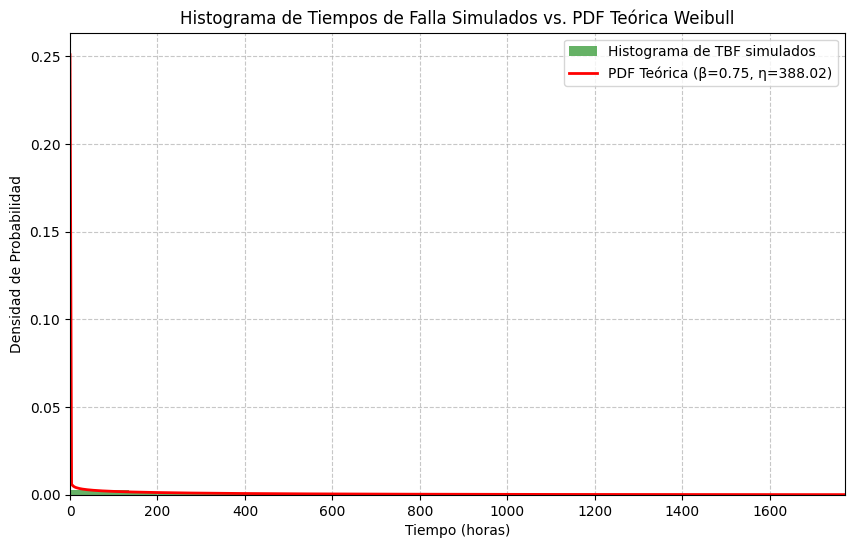

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# TODO 3b: histograma de la simulación + curva teórica de Weibull superpuesta

plt.figure(figsize=(10, 6))
plt.hist(simulated_tbf, bins=50, density=True, alpha=0.6, color='g', label='Histograma de TBF simulados')

# Curva teórica de Weibull PDF
# stats.weibull_min.pdf(x, c, loc, scale) donde c=beta, loc=0, scale=eta
x_limit = p90 * 1.5 # Ajustar el límite X a P90 * 1.5 para mejor visibilidad
x = np.linspace(1e-6, x_limit, 500) # Iniciar x desde un valor pequeño para evitar la división por cero
pdf_theoretical = stats.weibull_min.pdf(x, beta, loc=0, scale=eta)
plt.plot(x, pdf_theoretical, 'r-', lw=2, label=f'PDF Teórica (β={beta:.2f}, η={eta:.2f})')

plt.title('Histograma de Tiempos de Falla Simulados vs. PDF Teórica Weibull')
plt.xlabel('Tiempo (horas)')
plt.ylabel('Densidad de Probabilidad')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xlim(0, x_limit) # Set x-axis limit
plt.show()

**Pregunta final:** el β estimado debería salir menor a 1 (mortalidad infantil). Si tu resultado lo confirma, ¿qué tipo de acción de mantenimiento tiene más sentido para este compresor: cambiar piezas por tiempo fijo, o reforzar el control de calidad en la puesta en marcha? Justifica en 2-3 líneas.

 Un beta menor que 1 significa que la tasa de fallas disminuye con el tiempo, lo que sugiere que los activos que sobreviven al período inicial de 'infancia' tienden a durar más. Por lo tanto, mejorar los procesos de instalación, inspección inicial y rodaje del equipo ayudará a eliminar los defectos iniciales y a garantizar una vida útil más larga para los componentes que superen esta fase crítica, en lugar de un mantenimiento preventivo basado en tiempo fijo que no abordaría la causa raíz de las fallas tempranas.